In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from dataclasses import dataclass
from integrators.integration import BaseState, integrated, constant, tagged

from integrators.util import verbosePrint
from integrators.integration import *
from integrators.fields import *
import numpy as np
from dataclasses import dataclass        


$$
\begin{aligned}
\hat{k} &= k + \alpha e\\
\frac{dx}{dt} &= u&\\
m \frac{du}{dt} &= -\hat{k} x &- c u\\
\frac{de}{dt} &= \beta \text{sgn}(u) u^2 &- \gamma e
\end{aligned}
$$

In [2]:
m = 1.0
x_0 = 1.0
u_0 = 0.0
t_0 = 0.0
k_0 = 5
e_0 = m * u_0**2 / 2 + k_0 * x_0**2 / 2

x = torch.tensor([x_0])
u = torch.tensor([u_0])
e = torch.tensor([e_0]) 
t = torch.tensor([t_0])
k = torch.tensor([k_0])

alpha  = -5.0
beta = 0.5
gamma = 0.25
c = 0.1
print(f"Initial State: x={x.item()}, u={u.item()}, e={e.item()}, t={t.item()}, k={k.item()}")

Initial State: x=1.0, u=0.0, e=2.5, t=0.0, k=5


In [3]:


@dataclass
class HarmonicOscillatorState(BaseState):
    x: torch.Tensor = integrated('dxdt', tags=('position',))
    u: torch.Tensor = integrated('dudt', tags=('velocity',))
    e: torch.Tensor = integrated('dedt', tags=('hidden_energy', 'quantity'))
    k: torch.Tensor = constant(tags=('spring_constant',))
    m: torch.Tensor = constant(tags=('mass',))

    k_0: float = constant(tags=('base_spring_constant',))

    alpha: float = constant(tags=('alpha',))
    beta: float = constant(tags=('beta',))
    gamma: float = constant(tags=('gamma',))
    c: float = constant(tags=('damping',))

@dataclass
class OscillatorUpdate:
    dxdt: torch.Tensor = tagged(tags=('position_derivative',))
    dudt: torch.Tensor = tagged(tags=('velocity_derivative',))
    dedt: torch.Tensor = tagged(tags=('hidden_energy_derivative',))


In [4]:
@dataclass
class HarmonicOscillatorSystem(BaseIntegrationSystem):
    state: HarmonicOscillatorState = reference_state(tags=('oscillator_state',))
    t: float = 0.0
    def initializeNewState(self, *args, verbose=False, **kwargs):
        state = get_reference_state(self)
        verbosePrint(verbose, f'Initializing new state [t={self.t}, x={state.x.item()}, u={state.u.item()}, e={state.e.item()}]')
        return HarmonicOscillatorSystem(state=state.initializeNewState())
    
    def apply_position_update(self, update, spec: PositionUpdateSpec, **kwargs):
        return update_position(self, update, spec, 'position', 'position_derivative', 'velocity', 'velocity_derivative')
    def apply_velocity_update(self, update, spec: ComponentUpdateSpec, **kwargs):
        return update_component(self, update, spec, 'velocity', 'velocity_derivative')
    def apply_quantity_update(self, update, spec: ComponentUpdateSpec, **kwargs):
        return update_component(self, update, spec, 'hidden_energy', 'hidden_energy_derivative')
    def apply_state_update(self, update, spec: ComponentUpdateSpec, **kwargs):
        # Note: DO NOT advance self.t here. Time is managed by the integrator.
        position_spec = PositionUpdateSpec(derivative_dt=spec.derivative_dt, blend=spec.blend)
        self.apply_position_update(update, position_spec, **kwargs)
        self.apply_velocity_update(update, spec, **kwargs)
        self.apply_quantity_update(update, spec, **kwargs)
        return self
    
def f_modified_harmonic_system(system: HarmonicOscillatorSystem, dt: float, verbose: bool = False):
    state = get_reference_state(system)
    x = state.x
    u = state.u
    e = state.e
    m = state.m
    alpha = state.alpha
    beta = state.beta
    gamma = state.gamma
    c = state.c
    k_0 = state.k_0

    if verbose:
        print(f'\t[Step] t={system.t} x={x.item():.4f} u={u.item():.4f} e={e.item():.4f}')
    k_current = k_0 + alpha * e
    dxdt = u
    dudt = (-k_current * x - c * u) / m
    dedt = beta * torch.sign(u) * u**2 - gamma * e
    kinetic_energy = m * u**2 / 2
    potential_energy = k_current * x**2 / 2
    total_energy = kinetic_energy + potential_energy
    return OscillatorUpdate(dxdt, dudt, dedt), (k_current, kinetic_energy, potential_energy, total_energy)

In [ ]:
initialState = HarmonicOscillatorState(
    x=torch.tensor([x_0]),
    u=torch.tensor([u_0]),
    e=torch.tensor([e_0]) * 0,
    k=torch.tensor([k_0]),
    m=torch.tensor([m]),
    k_0=k_0,
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    c=c,
)
initialSystem = HarmonicOscillatorSystem(
    state=initialState,
)
def runIntegrator(initialSystem, integrationScheme, dt, time_limit):
    integrator = getIntegrator(integrationScheme)
    num_steps = int(time_limit / dt)
    kinetic_energy = torch.tensor([initialState.m * initialState.u**2 / 2])
    potential_energy = torch.tensor([k_0 * initialState.x**2 / 2])
    total_energy = kinetic_energy + potential_energy
    statesIntegrator = [(initialSystem, kinetic_energy, potential_energy, total_energy)]
    priorStep = None
    for step in range(num_steps):
        # print(f"Step {step+1}/{num_steps}")
        result = integrator.function(
            statesIntegrator[-1][0],
            dt=dt,
            f=f_modified_harmonic_system,
            verbose=False,
            priorStep=priorStep
        )
        # result is IntegrationResult with .state and .stages
        nextSystem = result.state
        priorStep = result.stages[-1]    # Store the last stage for the next iteration
        # priorStep = (result.stages[-1].update, result.stages[-1].aux)  # Store the last stage for the next iteration
        # Get auxiliary values from the last stage
        # Note: aux is wrapped in a tuple by split_return, so we unpack the first element
        aux_tuple = result.stages[-1].aux
        if aux_tuple and len(aux_tuple) == 1:
            k_current, kinetic_energy, potential_energy, total_energy = aux_tuple[0]
        else:
            raise ValueError(f"Unexpected aux format: {aux_tuple}")
        statesIntegrator.append((nextSystem, kinetic_energy, potential_energy, total_energy))

        # break
    return statesIntegrator, integrationScheme

dt = 0.01
time_limit = 10.0
trace_nystrom5, scheme_nystrom5 = runIntegrator(initialSystem, IntegrationSchemeType.nystrom5th, dt=dt, time_limit=time_limit)

Step 1/1000
Step 2/1000
[Integrator] Extracting k0 and r0 from priorStep NamedTuple with fields: ('aux', 'update') and values: StageResult(aux=((tensor([5.0000]), tensor([0.0008]), tensor([2.4992]), tensor([2.5000])),), update=OscillatorUpdate(dxdt=tensor([-0.0400]), dudt=tensor([-4.9952]), dedt=tensor([-0.0008])))
Step 3/1000
[Integrator] Extracting k0 and r0 from priorStep NamedTuple with fields: ('aux', 'update') and values: StageResult(aux=((tensor([5.0001]), tensor([0.0040]), tensor([2.4961]), tensor([2.5001])),), update=OscillatorUpdate(dxdt=tensor([-0.0899]), dudt=tensor([-4.9871]), dedt=tensor([-0.0040])))
Step 4/1000
[Integrator] Extracting k0 and r0 from priorStep NamedTuple with fields: ('aux', 'update') and values: StageResult(aux=((tensor([5.0004]), tensor([0.0098]), tensor([2.4905]), tensor([2.5003])),), update=OscillatorUpdate(dxdt=tensor([-0.1397]), dudt=tensor([-4.9768]), dedt=tensor([-0.0097])))
Step 5/1000
[Integrator] Extracting k0 and r0 from priorStep NamedTuple w

In [12]:

# schemes = [
#     # IntegrationSchemeType.forwardEuler,
#     # IntegrationSchemeType.rungeKutta2,
#     # IntegrationSchemeType.heunsMethod,
#     # IntegrationSchemeType.ralston2nd,
#     # IntegrationSchemeType.rungeKutta3,
#     # IntegrationSchemeType.heunsMethod3rd,
#     # IntegrationSchemeType.ralston3rd,
#     # IntegrationSchemeType.wray3rd,
#     # IntegrationSchemeType.sspRK3,
#     # IntegrationSchemeType.rungeKutta4,
#     # IntegrationSchemeType.rungeKutta4alt,
#     IntegrationSchemeType.leapFrog,
#     IntegrationSchemeType.symplecticEuler,
#     # IntegrationSchemeType.velocityVerlet,
#     # IntegrationSchemeType.pefrl,
#     # IntegrationSchemeType.vefrl,
#     # IntegrationSchemeType.epec,
#     # IntegrationSchemeType.epecModified,
#     # IntegrationSchemeType.tvdRK3,
#     # IntegrationSchemeType.tvdRK2,
#     # IntegrationSchemeType.semiImplicitEuler,
#     # IntegrationSchemeType.explicitEuler,
#     # IntegrationSchemeType.nystrom5th,
#     ]

schemes = []
order = 4
for integrationScheme in IntegrationSchemes:
    if integrationScheme.order == order:
        schemes.append(integrationScheme.identifier)
print(f"Running integrators of order {order}: {[scheme.name for scheme in schemes]}")

traces = []
for scheme in schemes:
    trace, scheme_used = runIntegrator(initialSystem, scheme, dt=dt, time_limit=time_limit)
    traces.append((trace, scheme_used))

Running integrators of order 4: ['rungeKutta4', 'rungeKutta4alt', 'pefrl', 'vefrl']
Step 1/1000
Step 2/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.0500]), dudt=tensor([-4.9938]), dedt=tensor([-0.0012])), ((tensor([5.0000]), tensor([0.0012]), tensor([2.4988]), tensor([2.5000])),))
Step 3/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.0999]), dudt=tensor([-4.9852]), dedt=tensor([-0.0050])), ((tensor([5.0002]), tensor([0.0050]), tensor([2.4951]), tensor([2.5001])),))
Step 4/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.1497]), dudt=tensor([-4.9744]), dedt=tensor([-0.0112])), ((tensor([5.0006]), tensor([0.0112]), tensor([2.4891]), tensor([2.5003])),))
Step 5/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.1993]), dudt=tensor([-4.9614]), dedt=tensor([-

[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.2983]), dudt=tensor([-4.9297]), dedt=tensor([-0.0443])), ((tensor([5.0044]), tensor([0.0445]), tensor([2.4575]), tensor([2.5020])),))
Step 8/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.3475]), dudt=tensor([-4.9112]), dedt=tensor([-0.0600])), ((tensor([5.0070]), tensor([0.0604]), tensor([2.4428]), tensor([2.5032])),))
Step 9/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.3965]), dudt=tensor([-4.8911]), dedt=tensor([-0.0781])), ((tensor([5.0105]), tensor([0.0786]), tensor([2.4261]), tensor([2.5047])),))
Step 10/1000
[Integrator] Extracting k0 and r0 from priorStep tuple with values: (OscillatorUpdate(dxdt=tensor([-0.4453]), dudt=tensor([-4.8694]), dedt=tensor([-0.0984])), ((tensor([5.0149]), tensor([0.0991]), tensor([2.4075]), tensor([2.5067])),))
Step 11/1000
[Integ

TypeError: f_modified_harmonic_system() got an unexpected keyword argument 'priorStep'

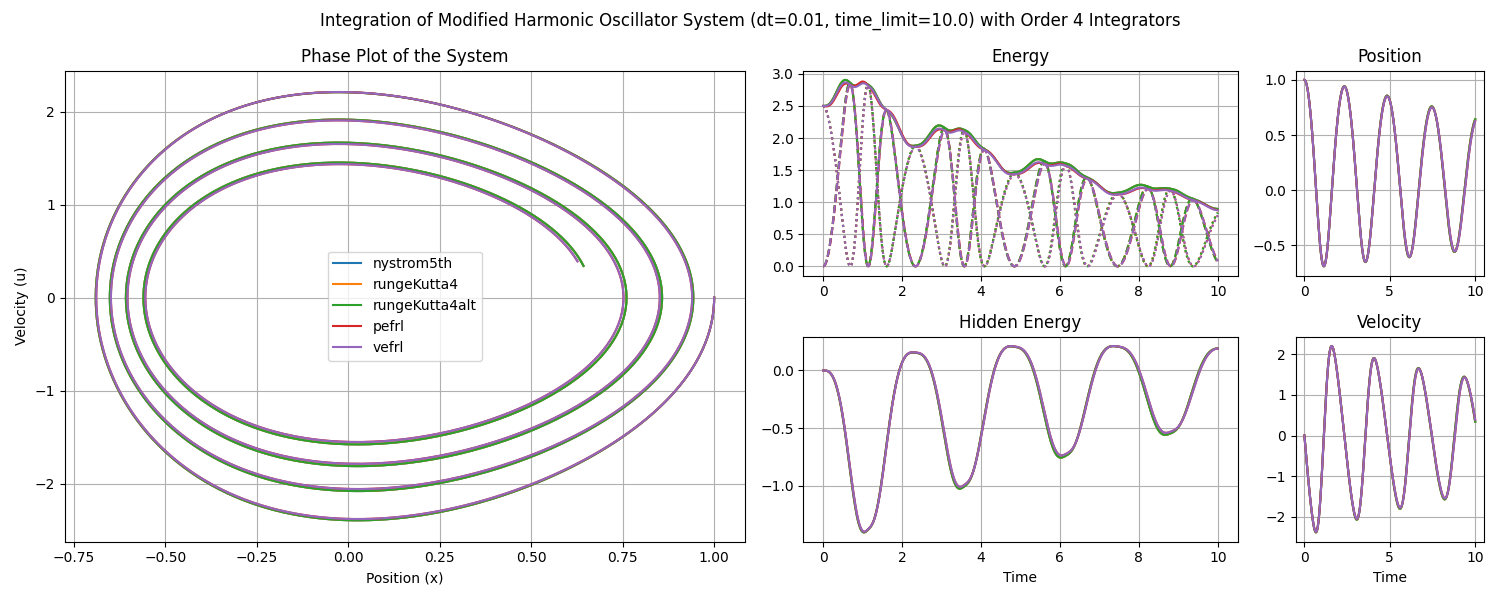

In [ ]:
fig, axis = plt.subplot_mosaic([
    ['A', 'A', 'A', 'B', 'B', 'C'],
    ['A', 'A', 'A', 'E', 'E', 'D'],
], figsize=(15, 6))
colorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

def system_value(system, tag):
    return get_tagged_attr(get_reference_state(system), tag=tag)

def plotTrace(fig, axis, trace, label, color):
    axis['A'].plot([system_value(state[0], 'position').item() for state in trace], [system_value(state[0], 'velocity').item() for state in trace], label=label, color=color)
    axis['B'].plot([state[0].t for state in trace], [state[1].item() for state in trace], ls='--', color=color)
    axis['B'].plot([state[0].t for state in trace], [state[2].item() for state in trace], ls=':', color=color)
    axis['B'].plot([state[0].t for state in trace], [state[3].item() for state in trace], label=label, color=color)
    axis['C'].plot([state[0].t for state in trace], [system_value(state[0], 'position').item() for state in trace], label=label, color=color)
    axis['D'].plot([state[0].t for state in trace], [system_value(state[0], 'velocity').item() for state in trace], label=label, color=color)
    axis['E'].plot([state[0].t for state in trace], [system_value(state[0], 'hidden_energy').item() for state in trace], label=label, color=color)

plotTrace(fig, axis, trace_nystrom5, label=scheme_nystrom5.name, color=colorCycle[0])
for i, (trace, scheme) in enumerate(traces):
    plotTrace(fig, axis, trace, label=scheme.name, color=colorCycle[(i+1) % len(colorCycle)])

axis['A'].set_xlabel('Position (x)')
axis['A'].set_ylabel('Velocity (u)')
axis['A'].set_title('Phase Plot of the System')
axis['A'].legend()
axis['A'].grid()
axis['B'].set_title('Energy')
axis['B'].grid()
axis['C'].set_title('Position')
axis['C'].grid()
axis['D'].set_xlabel('Time')
axis['D'].set_title('Velocity')
axis['D'].grid()
axis['E'].set_xlabel('Time')
axis['E'].set_title('Hidden Energy')
axis['E'].grid()

fig.suptitle(f'Integration of Modified Harmonic Oscillator System (dt={dt}, time_limit={time_limit}) with Order {order} Integrators')
fig.tight_layout()

fig.savefig(f'modified_harmonic_oscillator_order_{order}_integrators.png')


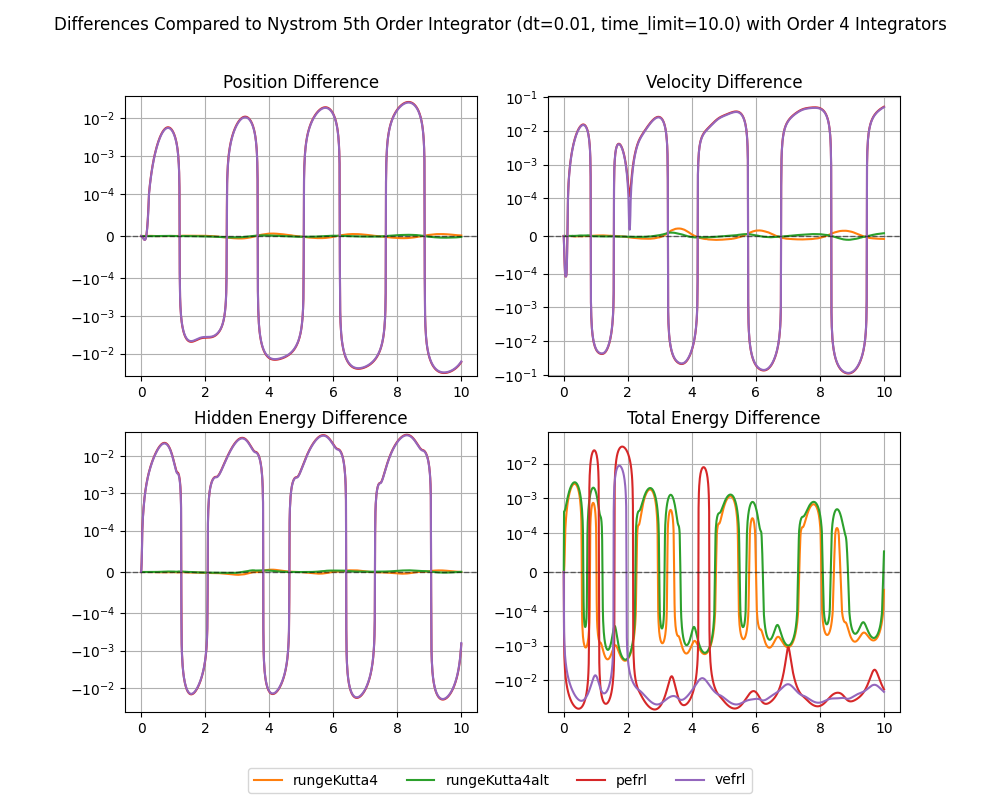

In [ ]:
fig, axis = plt.subplot_mosaic(
    """AB
    CD""",
    figsize=(10, 8))

def plotDifference(fig, axis, trace1, trace2, label, color):
    
    diff_x = np.array([system_value(state[0], 'position').item() for state in trace1]) - np.array([system_value(state[0], 'position').item() for state in trace2])
    diff_u = np.array([system_value(state[0], 'velocity').item() for state in trace1]) - np.array([system_value(state[0], 'velocity').item() for state in trace2])
    diff_e = np.array([system_value(state[0], 'hidden_energy').item() for state in trace1]) - np.array([system_value(state[0], 'hidden_energy').item() for state in trace2])
    diff_total_energy = np.array([state[3].item() for state in trace1]) - np.array([state[3].item() for state in trace2])
    axis['A'].plot([state[0].t for state in trace1], diff_x, label=label, color=color)
    axis['B'].plot([state[0].t for state in trace1], diff_u, label=label, color=color)
    axis['C'].plot([state[0].t for state in trace1], diff_e, label=label, color=color)
    axis['D'].plot([state[0].t for state in trace1], diff_total_energy, label=label, color=color)

for i, (trace, scheme) in enumerate(traces):
    plotDifference(fig, axis, trace, trace_nystrom5, label=f'{scheme.name}', color=colorCycle[(i + 1) % len(colorCycle)])
axis['A'].set_title('Position Difference')
axis['B'].set_title('Velocity Difference')
axis['C'].set_title('Hidden Energy Difference')
axis['D'].set_title('Total Energy Difference')

for ax in axis.values():
    ylim = ax.get_ylim()
    ax.set_ylim(max(abs(ylim[0]), abs(ylim[1])) * 1.1 * np.array([-1, 1]))
    ax.set_yscale('symlog', linthresh=1e-4)
    ax.grid(which='major', axis='both')
    ax.grid(which='minor', axis='y', ls=':', color='gray')
    ax.axhline(0, ls='--', color='black', lw=1, alpha = 0.5)

# Now add the legends below the plots
fig.suptitle(f'Differences Compared to Nystrom 5th Order Integrator (dt={dt}, time_limit={time_limit}) with Order {order} Integrators')
handles, labels = axis['A'].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, frameon=True)

fig.savefig(f'integrator_comparison_order_{order}.png', dpi=300)
# fig.tight_layout()